<a href="https://colab.research.google.com/github/maddygoodro/MIS433/blob/main/Assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [5]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb[['Released_Year']].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2016,28
2013,28
...,...
1936,1
1930,1
1921,1


In [6]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb.groupby('Released_Year').agg({'Released_Year':['min','max']}) #by running this I discovered the "Released_Year" for a movie has the value "PG"


Released_Year      
                        min   max
Released_Year                    
1920                   1920  1920
1921                   1921  1921
1922                   1922  1922
1924                   1924  1924
1925                   1925  1925
...                     ...   ...
2017                   2017  2017
2018                   2018  2018
2019                   2019  2019
2020                   2020  2020
PG                       PG    PG

[100 rows x 2 columns]

In [7]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966, 'Released_Year'] = 1995
imdb['Released_Year'].nunique()

100

In [8]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)
imdb['Released_Year'].dtype

dtype('int64')

In [10]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
imdb[(imdb.Released_Year >= 2010) & (imdb.IMDB_Rating >= 8.5)][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross', ascending = False)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?

#it's not in order and 2 rows have a null gross value. It's stored as a string right now so it's being sorted alphabetically and not numerically

In [12]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
#remove commas
#remove commas
imdb['Gross'] = imdb['Gross'].str.replace(',', '')
#convert to float
imdb['Gross'] = imdb['Gross'].astype(float)
imdb['Gross'].dtype

AttributeError: Can only use .str accessor with string values!

In [13]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross', ascending=False)

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [14]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe

imdb['Runtime_min'] = imdb['Runtime'].str.replace('min','')
imdb['Runtime_min'] = imdb['Runtime_min'].astype(int)
imdb['Runtime_min'].dtype

dtype('int64')

In [15]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year

imdb['Current_Year'] = 2026
imdb['Age_Year'] = (imdb['Current_Year'] - imdb['Released_Year'])
imdb['Age_Year']

,Age_Year
0,32
1,54
2,18
3,52
4,69
...,...
995,65
996,70
997,73
998,82


In [16]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.

#we did something similar with the 'flights' data
# //10 removes the last digit
# * 10 makes them all end with 0 again
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10
imdb['Decade']

,Decade
0,1990
1,1970
2,2000
3,1970
4,1950
...,...
995,1960
996,1950
997,1950
998,1940


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Meta_score')

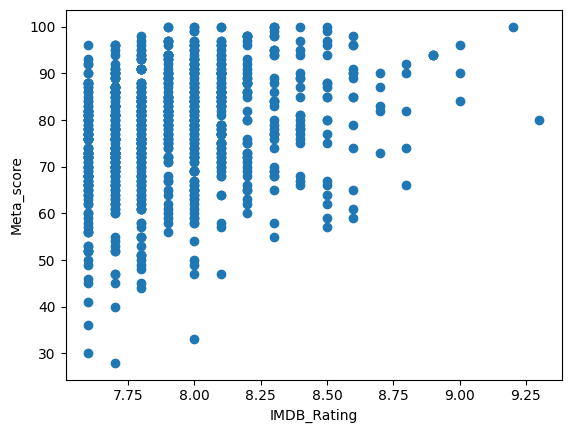

In [23]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.

plt.scatter(x='IMDB_Rating',y='Meta_score', data=imdb)
plt.xlabel('IMDB_Rating')
plt.ylabel('Meta_score')

#it looks like the IMDB rating and the meta score can be vastly different, and do not follow a clear trend where they correlate with each other.
# Suggests that there could be large differences between critics reviews and consumer reviews

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

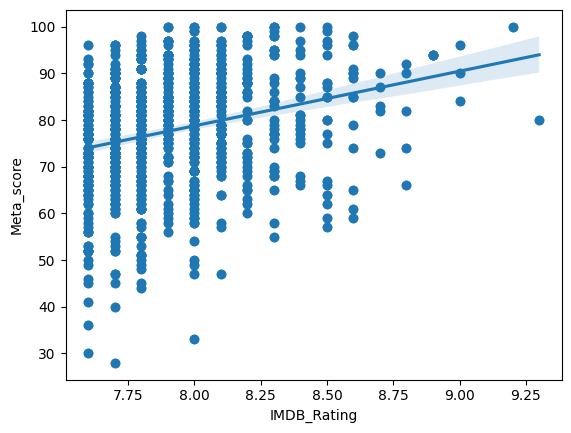

In [26]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
plt.scatter(x='IMDB_Rating',y='Meta_score', data=imdb)
plt.xlabel('IMDB_Rating')
plt.ylabel('Meta_score')
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb) #order 1, default. see below

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

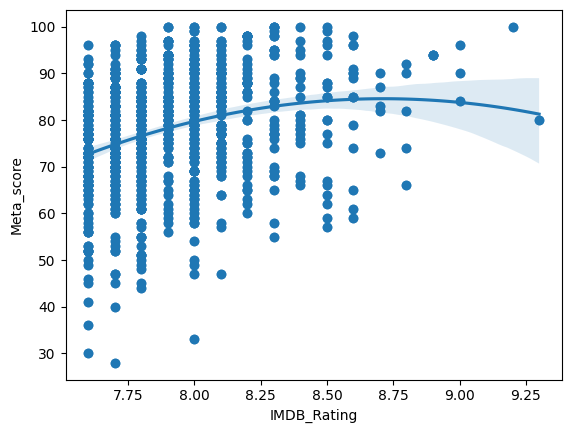

In [27]:
plt.scatter(x='IMDB_Rating',y='Meta_score', data=imdb)
plt.xlabel('IMDB_Rating')
plt.ylabel('Meta_score')
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=2)

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

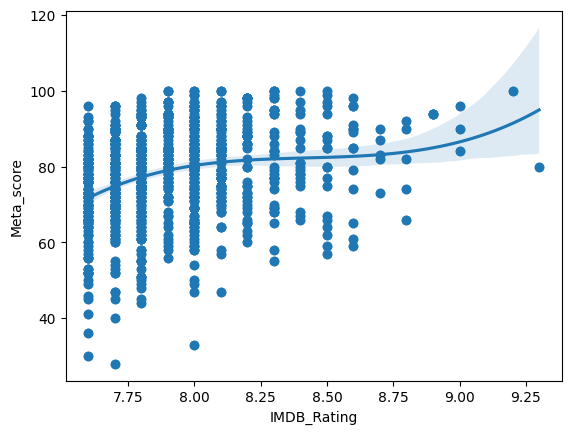

In [28]:
plt.scatter(x='IMDB_Rating',y='Meta_score', data=imdb)
plt.xlabel('IMDB_Rating')
plt.ylabel('Meta_score')
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=3)

In [30]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.

#the movie rated 8/10 (pretty good) on imdb but <40 on meta critic
imdb[(imdb['IMDB_Rating'] == 8.0) & (imdb['Meta_score'] < 40)][['Series_Title', 'IMDB_Rating', 'Meta_score']]  #movie is Tropa de Elite
#see below for more

,Series_Title,IMDB_Rating,Meta_score
356,Tropa de Elite,8.0,33.0


In [39]:
#movies rated 7/10 on imdb but <40 on meta critic. it feels like more movies should be rated well below a 7 on imdb
imdb[(imdb['IMDB_Rating'] <= 7.75) & (imdb['Meta_score'] <= 40)]

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Current_Year,Age_Year,Decade
735,https://m.media-amazon.com/images/M/MV5BMTgwNT...,Kai po che!,2013,U,130 min,"Drama, Sport",7.7,Three friends growing up in India at the turn ...,40.0,Abhishek Kapoor,Amit Sadh,Sushant Singh Rajput,Rajkummar Rao,Amrita Puri,32628,1122527.0,130,2026,13,2010
788,https://m.media-amazon.com/images/M/MV5BYzEyNz...,I Am Sam,2001,PG-13,132 min,Drama,7.7,A mentally handicapped man fights for custody ...,28.0,Jessie Nelson,Sean Penn,Michelle Pfeiffer,Dakota Fanning,Dianne Wiest,142863,40311852.0,132,2026,25,2000
917,https://m.media-amazon.com/images/M/MV5BMTU0Nz...,Seven Pounds,2008,UA,123 min,Drama,7.6,A man with a fateful secret embarks on an extr...,36.0,Gabriele Muccino,Will Smith,Rosario Dawson,Woody Harrelson,Michael Ealy,286770,69951824.0,123,2026,18,2000
942,https://m.media-amazon.com/images/M/MV5BODNiZm...,The Butterfly Effect,2004,U,113 min,"Drama, Sci-Fi, Thriller",7.6,Evan Treborn suffers blackouts during signific...,30.0,Eric Bress,J. Mackye Gruber,Ashton Kutcher,Amy Smart,Melora Walters,451479,57938693.0,113,2026,22,2000


Text(0, 0.5, 'Meta_score')

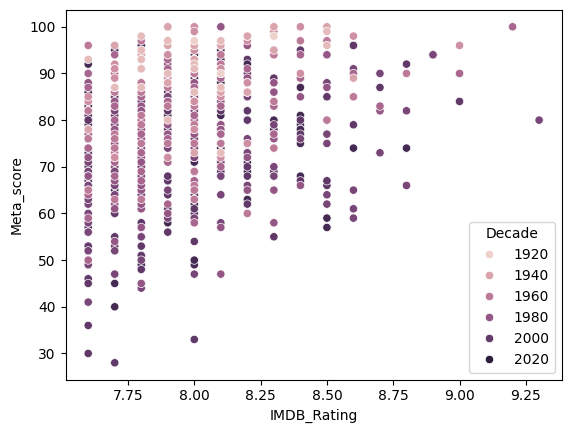

In [44]:
# In the scatterplot, use color to distinguish movies from different decades. #swithed to sns code
sns.scatterplot( data=imdb, x='IMDB_Rating',y='Meta_score', hue = 'Decade')
plt.xlabel('IMDB_Rating')
plt.ylabel('Meta_score')
#sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=1)

<Axes: xlabel='Decade', ylabel='count'>

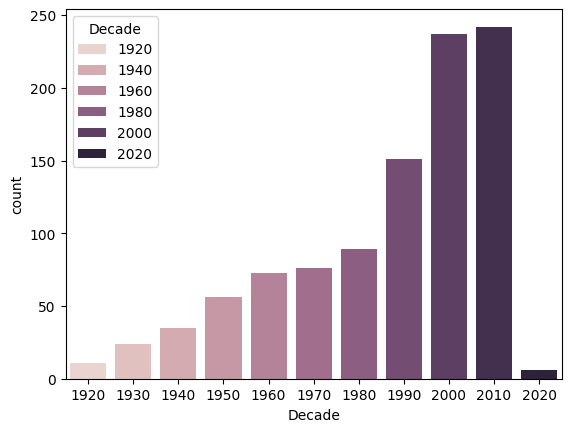

In [46]:
# Create a chart that shows how many movies fall in each decade.
sns.countplot(data=imdb, x='Decade', hue = 'Decade')

In [48]:
#column to calculate % by decade
decade_pct = imdb['Decade'].value_counts() * 100

Text(0, 0.5, '')

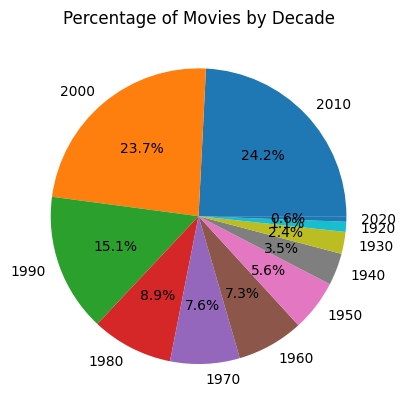

In [52]:
# Create a chart that shows the percentage of movies in each decade.
decade_pct.plot(kind='pie',autopct='%1.1f%%')   #the % part is to format the percentages and get them to appear in the pie chart
plt.title('Percentage of Movies by Decade')
plt.ylabel('')

In [55]:
imdb['Director'].value_counts()

,count
Director,
Alfred Hitchcock,14
Steven Spielberg,13
Hayao Miyazaki,11
Akira Kurosawa,10
Martin Scorsese,10
...,...
Kinji Fukasaku,1
Eric Bress,1
Thomas Kail,1


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Alfred Hitchcock'),
  Text(1, 0, 'Steven Spielberg'),
  Text(2, 0, 'Hayao Miyazaki'),
  Text(3, 0, 'Akira Kurosawa'),
  Text(4, 0, 'Martin Scorsese'),
  Text(5, 0, 'Woody Allen'),
  Text(6, 0, 'Stanley Kubrick'),
  Text(7, 0, 'Billy Wilder'),
  Text(8, 0, 'Clint Eastwood'),
  Text(9, 0, 'Christopher Nolan')])

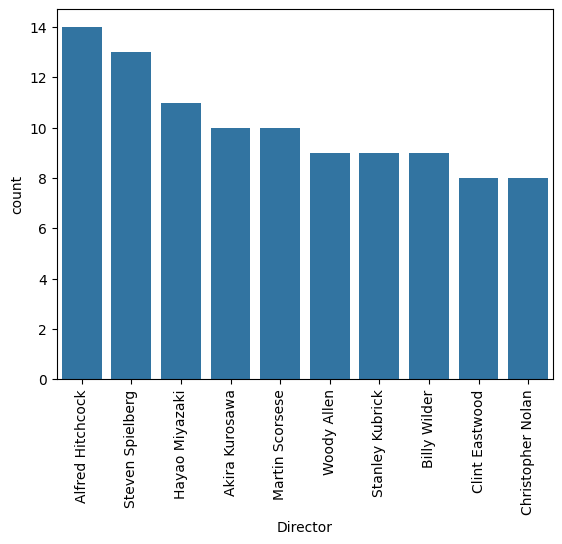

In [59]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.

#created new column
top_10_directors = imdb['Director'].value_counts().head(10).index
#return director name with movie count
sns.countplot(data=imdb[imdb['Director'].isin(top_10_directors)], x='Director', order=top_10_directors)
#must rotate the tick marks to make it readable
plt.xticks(rotation=90)

<Axes: xlabel='IMDB_Rating', ylabel='Gross'>

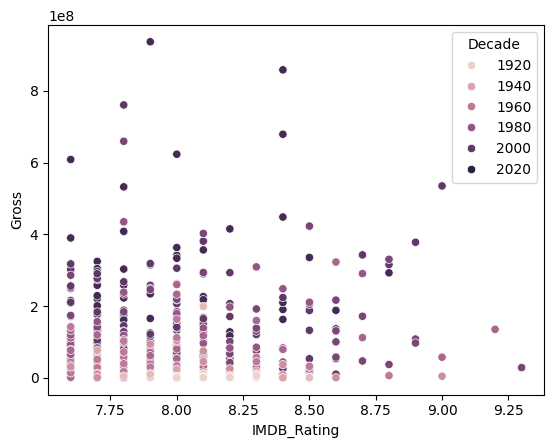

In [62]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
sns.scatterplot(data=imdb,x='IMDB_Rating',y='Gross', hue = 'Decade')

#No clear trend or correlation. The two best rated movies grossed very low. The 2 highest grossing movies were rated around 8 and 8.4

<Axes: ylabel='count'>

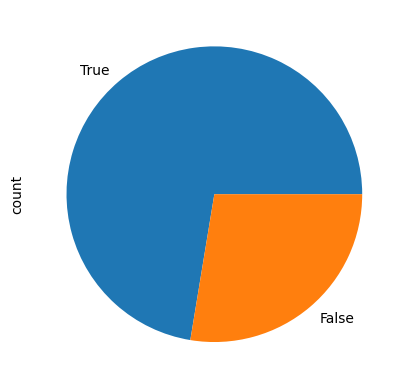

In [65]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = imdb['Genre'].str.contains('Drama')
imdb.Drama

imdb.Drama.value_counts().plot(kind='pie')

<Axes: xlabel='Decade', ylabel='Gross'>

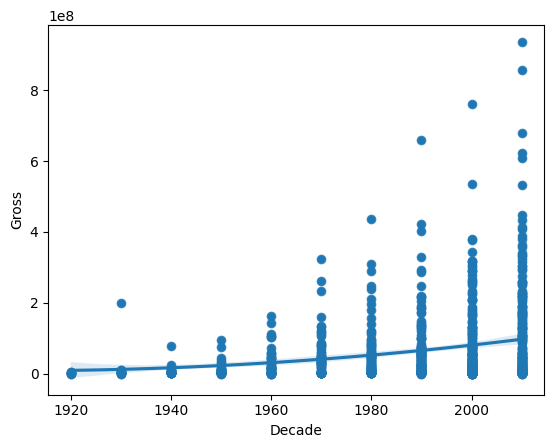

In [70]:
# Create a plot comparing gross revenue across decades.
sns.scatterplot(data=imdb,x='Decade',y='Gross')
sns.regplot(x='Decade',y='Gross',data=imdb, order=2)

/tmp/ipykernel_12824/3560871789.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gross_100mil['Drama_Category'] = gross_100mil['Drama'].map({True: 'Drama', False: 'Non-Drama'})


<Axes: xlabel='Gross', ylabel='Count'>

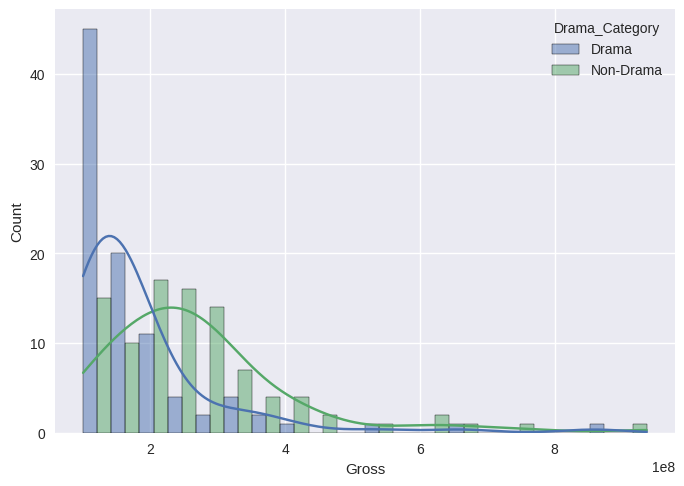

In [88]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

#gross over 100 million:
gross_100mil = imdb[imdb['Gross'] > 100000000]
#I wrote this line but the histogram was really ugly and didn't make sense (it was stacking the bars with grey) sns.histplot(data=gross_100mil, x='Gross', hue='Drama')

# Convert the boolean 'Drama' column to string labels for clearer plotting
gross_100mil['Drama_Category'] = gross_100mil['Drama'].map({True: 'Drama', False: 'Non-Drama'})

sns.histplot(data=gross_100mil, x='Gross', hue='Drama_Category', multiple='dodge', bins=20, kde=True)


<Axes: xlabel='IMDB_Rating', ylabel='Count'>

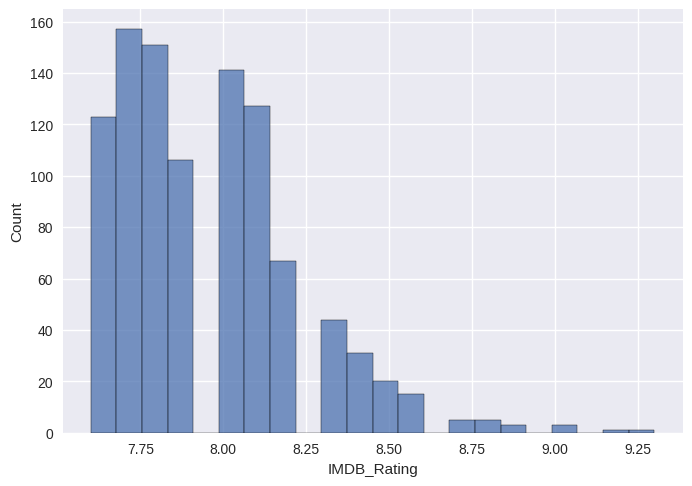

In [81]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: how are ratings distributed?
plt.style.use('seaborn-v0_8')
sns.histplot(imdb['IMDB_Rating'])

<Axes: xlabel='IMDB_Rating', ylabel='No_of_Votes'>

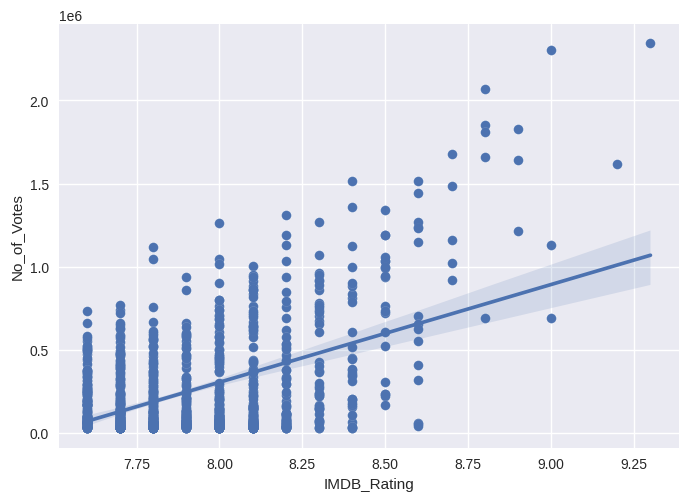

In [87]:
# Question 2: Comparison between number of votes and ratings. How do they compare/what is the relationship?
sns.scatterplot(data=imdb, x='IMDB_Rating', y='No_of_Votes')
sns.regplot(data=imdb,x='IMDB_Rating', y='No_of_Votes')
#positive correlation!